# car_selling_price_prediction_clean.ipynb



## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = '529m2j6u3elpcj'
os.environ['DataZoneDomainId'] = 'dzd-bvekavhzuwsa4z'
os.environ['DataZoneEnvironmentId'] = 'amoyu2ek1wr2mr'
os.environ['DataZoneDomainRegion'] = 'eu-north-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "529m2j6u3elpcj",
                "DataZoneDomainId": "dzd-bvekavhzuwsa4z",
                "DataZoneEnvironmentId": "amoyu2ek1wr2mr",
                "DataZoneDomainRegion": "eu-north-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

# Price prediction of cars based on SnapSoft preprocessed sample data using machine learning models
Since the company wants to sell its current inventory as
soon as possible, the preferred model slightly underestimates the price.


### Install and import necessary libraries

In [0]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline

np.random.seed(42)

## Loading data

In [0]:


df = pd.read_csv('s3://snapsoft-homework-curated-zone-tsz/ml_sample_data_snapsoft_preprocessed.csv')

print(df.shape)
df.head()

(235, 20)


,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
0,diesel,std,four,hatchback,fwd,front,95.7,yellow,166.3,64.4,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0
1,gas,std,four,wagon,4wd,front,95.7,purple,169.7,63.6,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0
2,gas,std,two,hatchback,rwd,front,98.4,navy,176.2,65.6,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0
3,gas,std,two,hatchback,rwd,front,102.9,fuchsia,183.5,67.7,52.0,3016,6.0,171,9.3,161.0,5200,19,24,15998.0
4,gas,std,four,sedan,fwd,front,100.4,yellow,184.6,66.5,55.1,3060,6.0,181,9.0,152.0,5200,19,25,13499.0


In [0]:
# Deduplication
before = len(df)
df = df.drop_duplicates()
print(f'Deduplication: removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

Deduplication: removed 0 duplicate rows. Remaining: 235


In [0]:
df.dtypes

fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
color                object
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
cylindernumber      float64
enginesize            int64
compressionratio    float64
horsepower          float64
peakrpm               int64
citympg               int64
highwaympg            int64
Price               float64
dtype: object

## Experimental data analysis

In [0]:
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,235.000000,231.000000,235.000000,235.000000,235.000000,227.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,98.576596,173.641558,65.840851,53.639574,2543.331915,4.361233,126.059574,10.180979,103.157447,5115.744681,25.370213,30.957447,13041.870923
std,5.883296,12.063445,2.090769,2.430998,509.763445,1.044113,40.195844,4.056151,38.420034,470.732039,6.506667,6.842419,7757.915869
min,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.050000,51.600000,2145.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.500000,25.000000,7775.000000
50%,96.500000,173.000000,65.400000,54.100000,2405.000000,4.000000,119.000000,9.000000,95.000000,5100.000000,24.000000,30.000000,9995.000000
75%,101.200000,180.250000,66.500000,55.500000,2921.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,35.000000,16501.500000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [0]:
df.isna().sum()

fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      9
wheelbase           0
color               0
carlength           4
carwidth            0
carheight           0
curbweight          0
cylindernumber      8
enginesize          0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
Price               0
dtype: int64

### Filling in missing values

In [0]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Categorical: fill with mode; numerical: fill with median
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == object or df[col].dtype == 'string':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print('\nMissing values after imputation:', df.isnull().sum().sum())

Missing values per column:
enginelocation    9
carlength         4
cylindernumber    8
dtype: int64

Missing values after imputation: 0


### Encoding Categorical Variables

In [0]:
df_encoded = df.copy()

# One-hot encode nominal columns with multiple unordered categories
ohe_cols = ['fueltype', 'carbody', 'drivewheel']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Label-encode the remaining categorical columns
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print('One-hot encoded:', ohe_cols)
print('Label encoded:', cat_cols)
print('Total features:', df_encoded.shape[1])

One-hot encoded: ['fueltype', 'carbody', 'drivewheel']
Label encoded: ['aspiration', 'doornumber', 'enginelocation', 'color']
Total features: 24


## Correlation Analysis

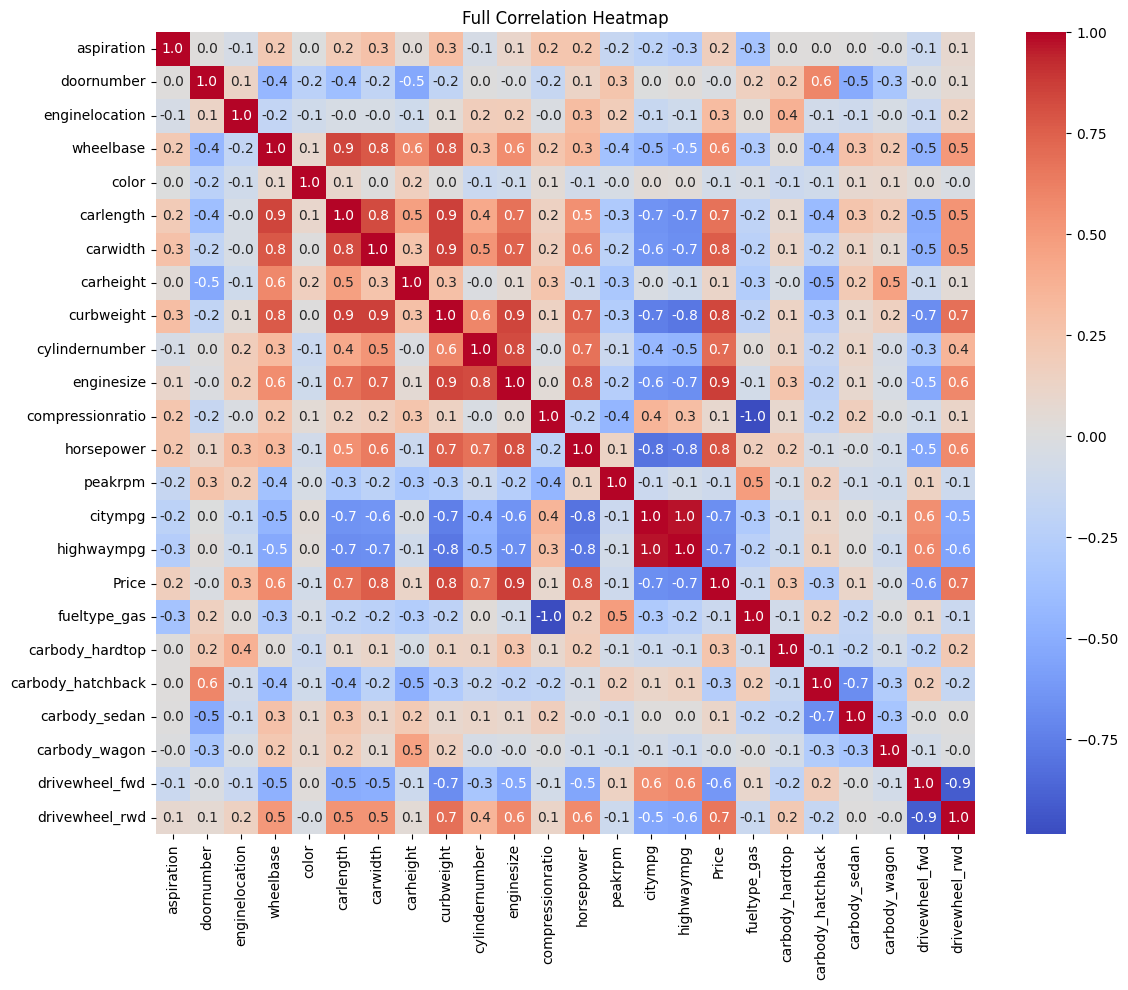

In [0]:
full_corr = df_encoded.corr()
corr = full_corr['Price'].drop('Price')

plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Full Correlation Heatmap')
plt.tight_layout()
plt.show()

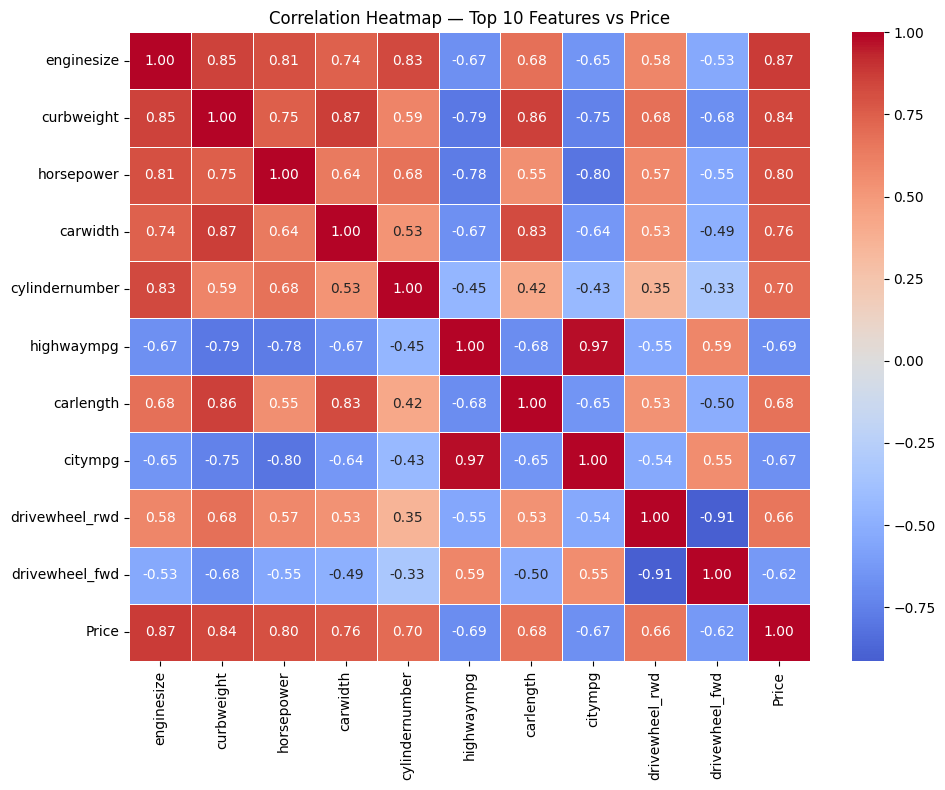

In [0]:
top_features = corr.abs().nlargest(10).index.tolist() + ['Price']

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_encoded[top_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Correlation Heatmap — Top 10 Features vs Price')
plt.tight_layout()
plt.show()

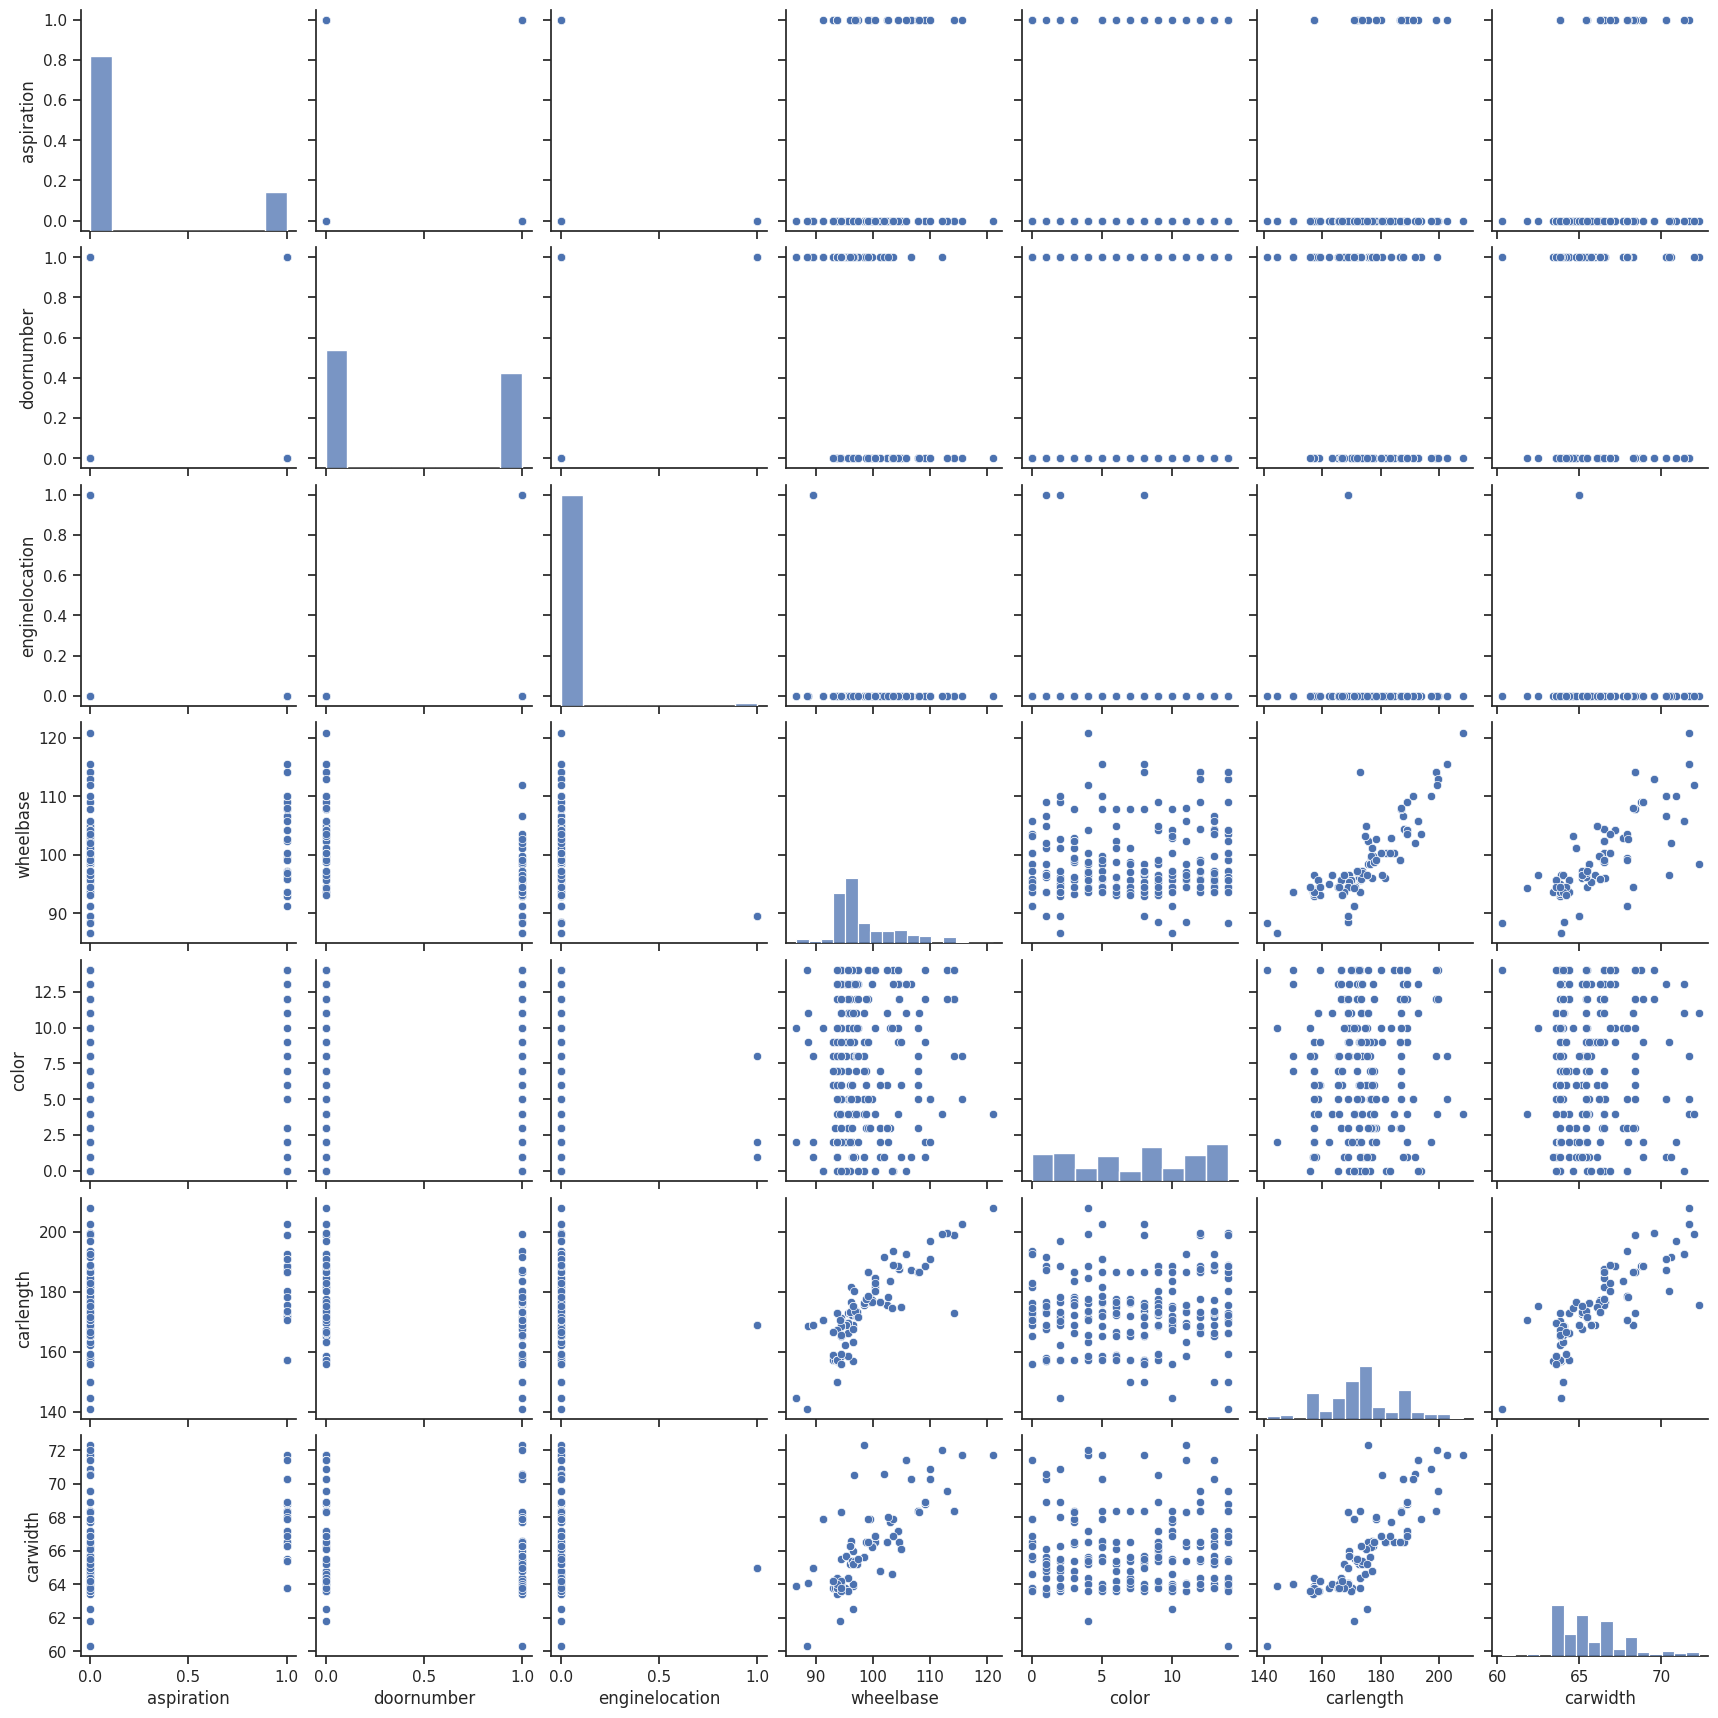

In [0]:
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(df_encoded.iloc[:, :7])
plt.show()

## Train Test Split and Scaling

In [0]:
# Split data into 3 parts: training 80%, validation 10%, test 10%
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_trainvalid, X_test, y_trainvalid, y_test = train_test_split(
    X, y, test_size=0.1, shuffle=True, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainvalid, y_trainvalid, test_size=1/9, shuffle=True, random_state=42
)

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(187, 23)
(24, 23)
(24, 23)


In [0]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)
print('Features scaled.')

Features scaled.


## Model Training

### Linear Regression model

In [0]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print('Linear Regression trained successfully.')

Linear Regression trained successfully.


### Random Forest model

In [0]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest trained successfully.')

Random Forest trained successfully.


### Gradient Boosting model

In [0]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)
print('Gradient Boosting trained successfully.')

Gradient Boosting trained successfully.


## Model Evaluation

In [0]:
def print_metrics(name, y_true_val, y_pred_val, y_true_test, y_pred_test):
    print(f'=== {name} ===')
    print(f'  Validation  — MAE: {mean_absolute_error(y_true_val, y_pred_val):.2f} | '
          f'RMSE: {np.sqrt(mean_squared_error(y_true_val, y_pred_val)):.2f} | '
          f'R²: {r2_score(y_true_val, y_pred_val):.4f}')
    print(f'  Test        — MAE: {mean_absolute_error(y_true_test, y_pred_test):.2f} | '
          f'RMSE: {np.sqrt(mean_squared_error(y_true_test, y_pred_test)):.2f} | '
          f'R²: {r2_score(y_true_test, y_pred_test):.4f}')

lr_valid_pred = lr_model.predict(X_valid_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)
rf_valid_pred = rf_model.predict(X_valid_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)
gb_valid_pred = gb_model.predict(X_valid_scaled)
gb_test_pred  = gb_model.predict(X_test_scaled)

print_metrics('Linear Regression',  y_valid, lr_valid_pred, y_test, lr_test_pred)
print()
print_metrics('Random Forest',  y_valid, rf_valid_pred, y_test, rf_test_pred)
print()
print_metrics('Gradient Boosting',  y_valid, gb_valid_pred, y_test, gb_test_pred)

=== Linear Regression ===
  Validation  — MAE: 1945.72 | RMSE: 2651.34 | R²: 0.8331
  Test        — MAE: 2756.27 | RMSE: 4399.42 | R²: 0.7747

=== Random Forest ===
  Validation  — MAE: 1128.67 | RMSE: 1545.50 | R²: 0.9433
  Test        — MAE: 1500.57 | RMSE: 2311.92 | R²: 0.9378

=== Gradient Boosting ===
  Validation  — MAE: 1048.84 | RMSE: 1443.16 | R²: 0.9506
  Test        — MAE: 1798.70 | RMSE: 2461.36 | R²: 0.9295


## Best Model Selection 

In [0]:

candidates = {
    'Linear Regression':  (lr_model, lr_valid_pred),
    'Random Forest':      (rf_model, rf_valid_pred),
    'Gradient Boosting':  (gb_model, gb_valid_pred),
}

test_mse = {name: mean_squared_error(y_valid, preds) for name, (_, preds) in candidates.items()}
test_mae = {name: mean_absolute_error(y_valid, preds) for name, (_, preds) in candidates.items()}

print('Test MSE scores:')
for name, score in test_mse.items():
    marker = '  < BEST' if name == min(test_mse, key=test_mse.get) else ''
    print(f'  {name}: {score:.2f}{marker}')

best_name = min(test_mse, key=test_mse.get)
best_model, best_test_pred = candidates[best_name]
print(f'\nBest model based on Test MSE: {best_name}')

print('\nTest MAE scores:')
for name, score in test_mae.items():
    marker = '  < BEST' if name == min(test_mae, key=test_mae.get) else ''
    print(f'  {name}: {score:.2f}{marker}')

best_name = min(test_mae, key=test_mae.get)
best_model, best_test_pred = candidates[best_name]
print(f'\nBest model based on Test MAE: {best_name}')


Test MSE scores:
  Linear Regression: 7029610.19
  Random Forest: 2388556.61
  Gradient Boosting: 2082711.23  < BEST

Best model based on Test MSE: Gradient Boosting

Test MAE scores:
  Linear Regression: 1945.72
  Random Forest: 1128.67
  Gradient Boosting: 1048.84  < BEST

Best model based on Test MAE: Gradient Boosting


### Based on MAE and MSE the best model is Gradient Boosting

## Checking which models estimations

In [0]:
avg_lr_error = np.mean( lr_test_pred-y_test)
avg_rf_error = np.mean(rf_test_pred-y_test)
avg_gb_error = np.mean(gb_test_pred-y_test)  

print(f'Average error (y_test - y_pred):')
print(f'  Linear Regression: {avg_lr_error:.2f}')   
print(f'  Random Forest: {avg_rf_error:.2f}')   
print(f'  Gradient Boosting: {avg_gb_error:.2f}')   



Average error (y_test - y_pred):
  Linear Regression: -789.80
  Random Forest: 432.64
  Gradient Boosting: 959.99


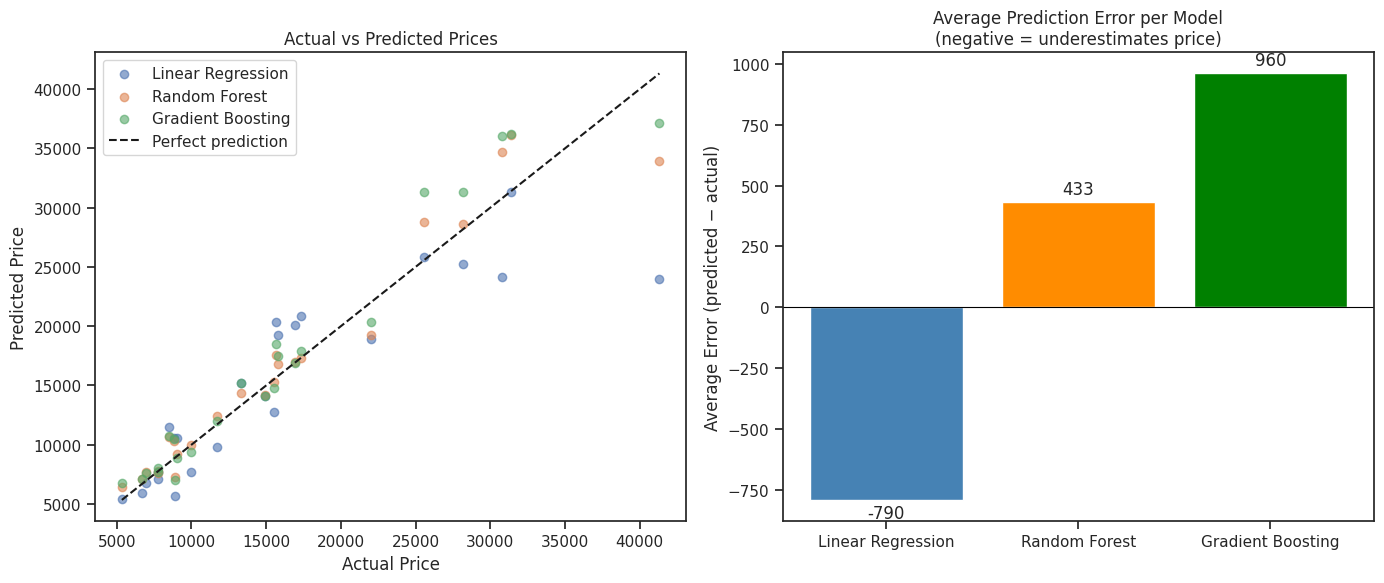

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: actual vs predicted prices
axes[0].scatter(y_test, lr_test_pred, alpha=0.6, label='Linear Regression')
axes[0].scatter(y_test, rf_test_pred, alpha=0.6, label='Random Forest')
axes[0].scatter(y_test, gb_test_pred, alpha=0.6, label='Gradient Boosting')
min_val = y_test.min()
max_val = y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()

# Bar chart: average error per model (negative = underestimates, positive = overestimates)
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
avg_errors = [avg_lr_error, avg_rf_error, avg_gb_error]
bars = axes[1].bar(model_names, avg_errors, color=['steelblue', 'darkorange', 'green'])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Average Error (predicted − actual)')
axes[1].set_title('Average Prediction Error per Model\n(negative = underestimates price)')
axes[1].bar_label(bars, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

### Best model is Gradient boosting regressior, while Linear Regression is the only which underestimates the price.

## Gradient boosting regressor fine tuning to underestimate slightly the predicted price

In [0]:
gb_model2 = GradientBoostingRegressor(loss='quantile', alpha=0.46, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model2.fit(X_train_scaled, y_train)
print('Gradient Boosting trained successfully.')

Gradient Boosting trained successfully.


In [0]:
gb_valid_pred2 = gb_model2.predict(X_valid_scaled)
gb_test_pred2  = gb_model2.predict(X_test_scaled)

In [0]:
# Full evaluation of the final model on both validation and test sets
print('=== Quantile Gradient Boosting (alpha=0.46) ===')
for split, y_true, y_pred in [('Validation', y_valid, gb_valid_pred2), ('Test', y_test, gb_test_pred2)]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    avg_err = np.mean(y_pred - y_true)
    direction = 'underestimates' if avg_err < 0 else 'overestimates'
    print(f'  {split:<12} — MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | '
          f'Avg error: {avg_err:.2f} ({direction})')

=== Quantile Gradient Boosting (alpha=0.46) ===
  Validation   — MAE: 1747.95 | RMSE: 2701.43 | R²: 0.8268 | Avg error: -450.65 (underestimates)
  Test         — MAE: 1530.78 | RMSE: 2268.39 | R²: 0.9401 | Avg error: -44.03 (underestimates)


In [0]:
avg_gb_error = np.mean(gb_test_pred2-y_test)  
print(f'  Gradient Boosting: {avg_gb_error:.2f}') 

  Gradient Boosting: -44.03


### By tweaking the params (alfa and loss) of the model it slightly underestimates the predicted price

## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()